In [160]:
#import library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [161]:
#load dataset
df = pd.read_csv('data_A (2).csv')
df.head()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0xa658,CUS_0x936d,March,Alistair Barrs,8466,703-48-3482,_______,100433.58,8074.465000,...,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,1,0x6739,CUS_0x9a29,August,Phila,25,339-28-0072,Developer,33119.82,3024.985000,...,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,2,0xdcf5,CUS_0x12a9,April,Driverb,44,583-20-9758,_______,44822.21,3555.184167,...,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,3,0x14453,CUS_0x3bad,June,Prasadc,29,510-25-2095,Musician,142081.48,11771.123333,...,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,4,0x1198e,CUS_0xa3e1,January,Poornimai,45,943-92-4350,Scientist,19267.27_,1374.605833,...,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


In [162]:
df.describe()


,Unnamed: 0,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,25000.000000,21417.000000,25000.000000,25000.000000,25000.000000,25000.000000,24494.000000,25000.000000,25000.000000
mean,12499.500000,4215.671131,17.235440,22.143080,71.214040,21.192000,28.149669,32.295884,1406.139718
std,7217.022701,3187.623134,118.307474,127.701822,463.669065,14.887254,194.452923,5.090592,8242.321932
min,0.000000,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.172942,0.000000
25%,6249.750000,1634.720833,4.000000,4.000000,8.000000,10.000000,3.000000,28.104589,30.750519
50%,12499.500000,3111.437500,6.000000,5.000000,13.000000,18.000000,6.000000,32.288376,70.523826
75%,18749.250000,5986.647500,7.000000,7.000000,20.000000,28.000000,9.000000,36.480066,163.598381
max,24999.000000,15167.180000,1798.000000,1499.000000,5775.000000,67.000000,2597.000000,48.489852,82236.000000


In [163]:
df.shape


(25000, 29)

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22440 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21417 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

In [165]:
df.columns

Index(['Unnamed: 0', 'ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN',
       'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [166]:
df["Credit_Score"].value_counts()

Credit_Score
Standard    13330
Poor         7302
Good         4368
Name: count, dtype: int64

In [167]:
#jumlah missing value
df.isnull().sum().sort_values(ascending=False)

Monthly_Inhand_Salary       3583
Type_of_Loan                2828
Name                        2560
Credit_History_Age          2249
Num_of_Delayed_Payment      1733
Amount_invested_monthly     1164
Num_Credit_Inquiries         506
Monthly_Balance              289
Age                            0
Month                          0
Unnamed: 0                     0
Customer_ID                    0
ID                             0
Interest_Rate                  0
Num_Credit_Card                0
Num_Bank_Accounts              0
Annual_Income                  0
SSN                            0
Occupation                     0
Delay_from_due_date            0
Num_of_Loan                    0
Outstanding_Debt               0
Credit_Mix                     0
Changed_Credit_Limit           0
Credit_Utilization_Ratio       0
Total_EMI_per_month            0
Payment_of_Min_Amount          0
Payment_Behaviour              0
Credit_Score                   0
dtype: int64

In [168]:
df.duplicated().sum()

np.int64(0)

In [169]:
# Missing Value dalam Persentase

missing_df = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
}).sort_values(by="Missing_Count", ascending=False)

missing_df[missing_df["Missing_Count"] > 0]


,Missing_Count,Missing_Percentage
Monthly_Inhand_Salary,3583,14.332
Type_of_Loan,2828,11.312
Name,2560,10.240
Credit_History_Age,2249,8.996
Num_of_Delayed_Payment,1733,6.932
Amount_invested_monthly,1164,4.656
Num_Credit_Inquiries,506,2.024
Monthly_Balance,289,1.156


In [170]:
object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    print("="*60)
    print(col)
    print(df[col].dropna().unique()[:15])

ID
['0xa658' '0x6739' '0xdcf5' '0x14453' '0x1198e' '0x241ce' '0x84e0'
 '0xc7a3' '0x23a68' '0x227d' '0x13f69' '0x1b8e7' '0x15aa1' '0x515f'
 '0x5c71']
Customer_ID
['CUS_0x936d' 'CUS_0x9a29' 'CUS_0x12a9' 'CUS_0x3bad' 'CUS_0xa3e1'
 'CUS_0x5e18' 'CUS_0x2e1d' 'CUS_0xb4c5' 'CUS_0xb4fd' 'CUS_0x6b44'
 'CUS_0x8031' 'CUS_0x6f0f' 'CUS_0x715f' 'CUS_0xb713' 'CUS_0x1cc3']
Month
['March' 'August' 'April' 'June' 'January' 'February' 'May' 'July']
Name
['Alistair Barrs' 'Phila' 'Driverb' 'Prasadc' 'Poornimai' 'Kuehnenn'
 'Nanette Byrness' 'Michaelj' 'Chris Reesej' 'Dan Levined' 'Cruises'
 'Joseph Axs' 'Kims' 'Aaronf' 'David Frenchq']
Age
['8466' '25' '44' '29' '45' '49' '18' '51' '27' '39_' '19' '35' '46' '56'
 '28']
SSN
['703-48-3482' '339-28-0072' '583-20-9758' '510-25-2095' '943-92-4350'
 '287-80-7372' '408-57-4420' '873-29-1123' '400-77-1931' '453-58-1018'
 '146-48-0684' '071-03-6872' '#F%$D@*&8' '578-67-3819' '436-19-3706']
Occupation
['_______' 'Developer' 'Musician' 'Scientist' 'Entrepreneur' 'Ac

In [171]:
df[object_cols].nunique().sort_values(ascending=False)

ID                         25000
Monthly_Balance            24708
Amount_invested_monthly    22759
Annual_Income              12889
Customer_ID                11252
Outstanding_Debt           11218
SSN                        11037
Name                        9027
Type_of_Loan                5740
Changed_Credit_Limit        3411
Age                          520
Credit_History_Age           404
Num_of_Delayed_Payment       240
Num_of_Loan                  127
Occupation                    16
Month                          8
Payment_Behaviour              7
Credit_Mix                     4
Payment_of_Min_Amount          3
Credit_Score                   3
dtype: int64

## Cleaning Data

In [172]:
# Copy Dataset
df_clean = df.copy()

# Hapus Kolom Identifier
drop_cols = ["Unnamed: 0", "ID", "Customer_ID", "Name", "SSN"]

df_clean = df_clean.drop(columns=drop_cols)

df_clean.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,March,8466,_______,100433.58,8074.465000,1,5,10,2,"Student Loan, and Debt Consolidation Loan",...,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,August,25,Developer,33119.82,3024.985000,10,5,32,5,"Home Equity Loan, Mortgage Loan, Home Equity L...",...,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,April,44,_______,44822.21,3555.184167,1,4,2,4,"Credit-Builder Loan, Debt Consolidation Loan, ...",...,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,June,29,Musician,142081.48,11771.123333,6,6,15,3_,"Personal Loan, Not Specified, and Mortgage Loan",...,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,January,45,Scientist,19267.27_,1374.605833,10,8,25,6,"Home Equity Loan, Auto Loan, Payday Loan, Not ...",...,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


In [173]:
# Bersihkan Nilai Tidak Valid pada Kolom Kategorikal
df_clean["Occupation"] = df_clean["Occupation"].replace("_______", np.nan)
df_clean["Credit_Mix"] = df_clean["Credit_Mix"].replace("_", np.nan)
df_clean["Payment_Behaviour"] = df_clean["Payment_Behaviour"].replace("!@9#%8", np.nan)
df_clean["Payment_of_Min_Amount"] = df_clean["Payment_of_Min_Amount"].replace("NM", np.nan)

In [174]:
# Bersihkan dan Konversi Kolom Numerik yang Masih Object
# Catatan: "Monthly_Balance" juga dimasukkan ke daftar ini karena pada data_A
# kolom tersebut ternyata masih mengandung karakter underscore (bukan hanya
# Age, Annual_Income, dll seperti pada contoh), sehingga perlu dibersihkan juga.

num_object_cols = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

for col in num_object_cols:
    df_clean[col] = df_clean[col].astype(str).str.replace("_", "", regex=False)
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

In [175]:
# Konversi Credit History Age ke Bulan
import re

def convert_credit_history_age(value):
    if pd.isnull(value):
        return np.nan

    value = str(value)

    years = re.search(r"(\d+)\sYears?", value)
    months = re.search(r"(\d+)\sMonths?", value)

    year_value = int(years.group(1)) if years else 0
    month_value = int(months.group(1)) if months else 0

    return (year_value * 12) + month_value

df_clean["Credit_History_Age"] = df_clean["Credit_History_Age"].apply(convert_credit_history_age)

In [176]:
# Cek Tipe Data Setelah Cleaning
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  int64  
 2   Occupation                23230 non-null  object 
 3   Annual_Income             25000 non-null  float64
 4   Monthly_Inhand_Salary     21417 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  int64  
 9   Type_of_Loan              22172 non-null  object 
 10  Delay_from_due_date       25000 non-null  int64  
 11  Num_of_Delayed_Payment    23267 non-null  float64
 12  Changed_Credit_Limit      24482 non-null  float64
 13  Num_Credit_Inquiries      24494 non-null  float64
 14  Credit

In [177]:
# Cek Missing Value Setelah Cleaning
missing_after_cleaning = pd.DataFrame({
    "Missing_Count": df_clean.isnull().sum(),
    "Missing_Percentage": (df_clean.isnull().sum() / len(df_clean)) * 100
}).sort_values(by="Missing_Count", ascending=False)

missing_after_cleaning[missing_after_cleaning["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Credit_Mix,5066,20.264
Monthly_Inhand_Salary,3583,14.332
Payment_of_Min_Amount,3000,12.000
Type_of_Loan,2828,11.312
Credit_History_Age,2249,8.996
Payment_Behaviour,1852,7.408
Occupation,1770,7.080
Num_of_Delayed_Payment,1733,6.932
Amount_invested_monthly,1164,4.656
Changed_Credit_Limit,518,2.072


In [178]:
# Cek Statistik Setelah Cleaning
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,25000.0,1.052066e+02,6.633176e+02,-5.000000e+02,24.000000,33.000000,42.000000,8.698000e+03
Annual_Income,25000.0,1.918058e+05,1.531878e+06,7.005930e+03,19559.450000,37813.630000,73096.780000,2.418881e+07
Monthly_Inhand_Salary,21417.0,4.215671e+03,3.187623e+03,3.036454e+02,1634.720833,3111.437500,5986.647500,1.516718e+04
Num_Bank_Accounts,25000.0,1.723544e+01,1.183075e+02,-1.000000e+00,4.000000,6.000000,7.000000,1.798000e+03
Num_Credit_Card,25000.0,2.214308e+01,1.277018e+02,0.000000e+00,4.000000,5.000000,7.000000,1.499000e+03
Interest_Rate,25000.0,7.121404e+01,4.636691e+02,1.000000e+00,8.000000,13.000000,20.000000,5.775000e+03
Num_of_Loan,25000.0,2.847240e+00,6.177417e+01,-1.000000e+02,1.000000,3.000000,5.000000,1.482000e+03
Delay_from_due_date,25000.0,2.119200e+01,1.488725e+01,-5.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,23267.0,3.039829e+01,2.226172e+02,-3.000000e+00,9.000000,14.000000,18.000000,4.388000e+03
Changed_Credit_Limit,24482.0,1.038095e+01,6.768413e+00,-6.430000e+00,5.290000,9.440000,14.827500,3.629000e+01


## Invalid values and outlier check

In [179]:
# Cek Daftar Kolom Numerik
num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
num_cols

Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance'],
      dtype='object')

In [180]:
# Cek Ringkasan Min, Q1, Median, Q3, dan Max
num_summary = pd.DataFrame({
    "Min": df_clean[num_cols].min(),
    "Q1": df_clean[num_cols].quantile(0.25),
    "Median": df_clean[num_cols].median(),
    "Q3": df_clean[num_cols].quantile(0.75),
    "Max": df_clean[num_cols].max()
})

num_summary

,Min,Q1,Median,Q3,Max
Age,-5.000000e+02,24.000000,33.000000,42.000000,8.698000e+03
Annual_Income,7.005930e+03,19559.450000,37813.630000,73096.780000,2.418881e+07
Monthly_Inhand_Salary,3.036454e+02,1634.720833,3111.437500,5986.647500,1.516718e+04
Num_Bank_Accounts,-1.000000e+00,4.000000,6.000000,7.000000,1.798000e+03
Num_Credit_Card,0.000000e+00,4.000000,5.000000,7.000000,1.499000e+03
Interest_Rate,1.000000e+00,8.000000,13.000000,20.000000,5.775000e+03
Num_of_Loan,-1.000000e+02,1.000000,3.000000,5.000000,1.482000e+03
Delay_from_due_date,-5.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,-3.000000e+00,9.000000,14.000000,18.000000,4.388000e+03
Changed_Credit_Limit,-6.430000e+00,5.290000,9.440000,14.827500,3.629000e+01


In [181]:
# Cek Invalid Value Berdasarkan Logika Data
invalid_checks = {
    "Age < 0": (df_clean["Age"] < 0).sum(),
    "Age > 100": (df_clean["Age"] > 100).sum(),

    "Num_Bank_Accounts < 0": (df_clean["Num_Bank_Accounts"] < 0).sum(),
    "Num_Bank_Accounts > 20": (df_clean["Num_Bank_Accounts"] > 20).sum(),

    "Num_Credit_Card > 20": (df_clean["Num_Credit_Card"] > 20).sum(),

    "Interest_Rate > 100": (df_clean["Interest_Rate"] > 100).sum(),

    "Num_of_Loan < 0": (df_clean["Num_of_Loan"] < 0).sum(),
    "Num_of_Loan > 20": (df_clean["Num_of_Loan"] > 20).sum(),

    "Delay_from_due_date < 0": (df_clean["Delay_from_due_date"] < 0).sum(),

    "Num_of_Delayed_Payment < 0": (df_clean["Num_of_Delayed_Payment"] < 0).sum(),
    "Num_of_Delayed_Payment > 100": (df_clean["Num_of_Delayed_Payment"] > 100).sum(),

    "Num_Credit_Inquiries > 100": (df_clean["Num_Credit_Inquiries"] > 100).sum()
}

invalid_df = pd.DataFrame.from_dict(
    invalid_checks,
    orient="index",
    columns=["Invalid_Count"]
)

invalid_df

,Invalid_Count
Age < 0,226
Age > 100,440
Num_Bank_Accounts < 0,4
Num_Bank_Accounts > 20,335
Num_Credit_Card > 20,562
Interest_Rate > 100,475
Num_of_Loan < 0,979
Num_of_Loan > 20,109
Delay_from_due_date < 0,167
Num_of_Delayed_Payment < 0,156


In [182]:
# Cek Dirty Value dari Dataset Asli
dirty_checks = {
    "Annual_Income contains '_'": df["Annual_Income"].astype(str).str.contains("_", regex=False).sum(),
    "Num_of_Loan contains '_'": df["Num_of_Loan"].astype(str).str.contains("_", regex=False).sum(),
    "Amount_invested_monthly contains '__'": df["Amount_invested_monthly"].astype(str).str.contains("__", regex=False).sum(),
    "Monthly_Balance contains '__'": df["Monthly_Balance"].astype(str).str.contains("__", regex=False).sum(),
    "Changed_Credit_Limit contains '_'": df["Changed_Credit_Limit"].astype(str).str.contains("_", regex=False).sum(),
    "Occupation == '_______'": (df["Occupation"] == "_______").sum(),
    "Credit_Mix == '_'": (df["Credit_Mix"] == "_").sum(),
    "Payment_Behaviour == '!@9#%8'": (df["Payment_Behaviour"] == "!@9#%8").sum(),
    "Payment_of_Min_Amount == 'NM'": (df["Payment_of_Min_Amount"] == "NM").sum()
}

dirty_df = pd.DataFrame.from_dict(
    dirty_checks,
    orient="index",
    columns=["Dirty_Count"]
)

dirty_df

,Dirty_Count
Annual_Income contains '_',1756
Num_of_Loan contains '_',1216
Amount_invested_monthly contains '__',1035
Monthly_Balance contains '__',4
Changed_Credit_Limit contains '_',518
Occupation == '_______',1770
Credit_Mix == '_',5066
Payment_Behaviour == '!@9#%8',1852
Payment_of_Min_Amount == 'NM',3000


In [183]:
# Cek Potential Outlier dengan IQR
outlier_summary = []

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    outlier_percentage = (outlier_count / len(df_clean)) * 100

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_count,
        "Outlier_Percentage": outlier_percentage
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values(
    by="Outlier_Count",
    ascending=False
)

outlier_df

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
15,Amount_invested_monthly,-212.632276,553.046859,2484,9.936
16,Monthly_Balance,-28.063047,767.398978,1896,7.584
14,Total_EMI_per_month,-168.521274,362.870174,1671,6.684
11,Outstanding_Debt,-1529.312500,4056.707500,1286,5.144
6,Num_of_Loan,-5.000000,11.000000,1089,4.356
7,Delay_from_due_date,-17.000000,55.000000,1017,4.068
1,Annual_Income,-60746.545000,153402.775000,703,2.812
0,Age,-3.000000,69.000000,667,2.668
4,Num_Credit_Card,-0.500000,11.500000,564,2.256
5,Interest_Rate,-10.000000,38.000000,479,1.916


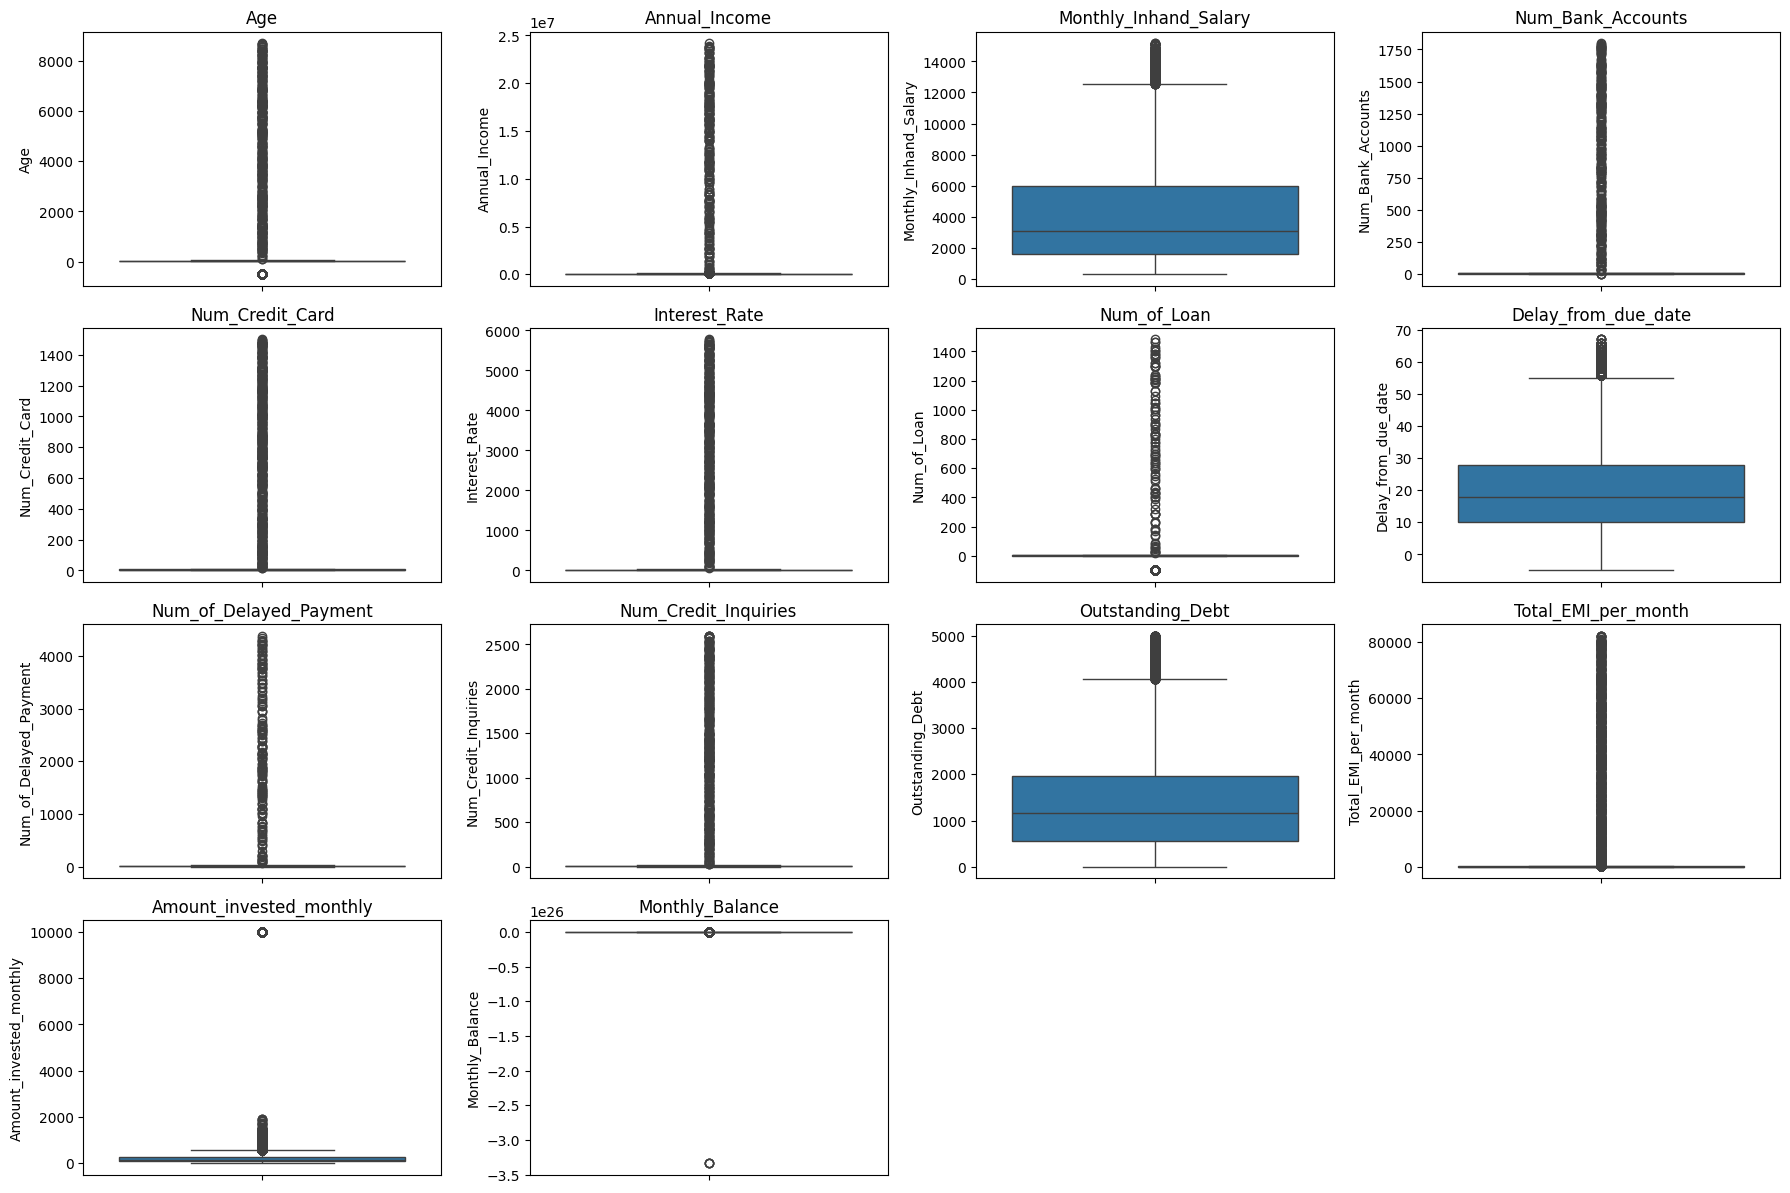

In [184]:
# Boxplot Kolom Numerik Utama
selected_outlier_cols = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

plt.figure(figsize=(18, 12))

for i, col in enumerate(selected_outlier_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df_clean[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## Insight from checking invalid values and outliers
---
Dari pengecekan nilai numerik, ditemukan nilai yang tidak realistis, seperti umur negatif (226 baris) atau lebih dari 100 tahun (440 baris), `Num_Bank_Accounts` bernilai negatif (4 baris) atau di atas 20 (335 baris), serta nilai `Interest_Rate` lebih dari 100% (475 baris). Selain itu, terdapat nilai negatif pada `Num_of_Delayed_Payment` (156 baris) dan `Num_Credit_Inquiries` lebih dari 100 (410 baris). Nilai-nilai ini tidak logis sehingga perlu ditangani sebagai nilai tidak valid.

Ada juga dirty value dengan karakter underscore pada `Annual_Income` (1.756 baris) dan `Num_of_Loan` (1.216 baris). `Amount_invested_monthly` memiliki 1.035 baris yang mengandung double underscore, sementara `Monthly_Balance` terdapat 4 baris dengan pola serupa, termasuk nilai ekstrem yang menunjukkan dirty sentinel value. Ini perlu penanganan khusus.

Berdasarkan IQR, fitur dengan proporsi outlier tertinggi adalah `Amount_invested_monthly` (9,94%), dan lainnya. Outlier ini mungkin masih relevan secara bisnis, jadi tidak dihapus langsung, namun akan ditandai. Selanjutnya, nilai yang jelas tidak valid diubah menjadi missing value untuk imputasi, sedangkan outlier yang masuk akal tetap dipertahankan.


## Handling Dirty and Invalid Values 
---
Pada tahap ini, nilai yang tidak valid akan ditangani berdasarkan logika data dan diubah menjadi missing value untuk imputasi. Nilai negatif pada `Delay_from_due_date` diubah menjadi 0. Dirty sentinel value pada `Amount_invested_monthly` dan `Monthly_Balance` ditangani secara terpisah.

In [185]:
# Copy Data untuk Preprocessing
df_prep = df_clean.copy()

In [186]:
# Ubah Invalid Value Menjadi Missing Value

# Age: umur negatif atau terlalu besar tidak realistis
df_prep.loc[(df_prep["Age"] < 0) | (df_prep["Age"] > 100), "Age"] = np.nan

# Jumlah akun bank tidak boleh negatif atau terlalu ekstrem
df_prep.loc[(df_prep["Num_Bank_Accounts"] < 0) | (df_prep["Num_Bank_Accounts"] > 20), "Num_Bank_Accounts"] = np.nan

# Jumlah kartu kredit terlalu tinggi dianggap tidak wajar
df_prep.loc[df_prep["Num_Credit_Card"] > 20, "Num_Credit_Card"] = np.nan

# Interest rate di atas 100 dianggap tidak realistis
df_prep.loc[df_prep["Interest_Rate"] > 100, "Interest_Rate"] = np.nan

# Jumlah pinjaman negatif atau terlalu besar dianggap tidak valid
df_prep.loc[(df_prep["Num_of_Loan"] < 0) | (df_prep["Num_of_Loan"] > 20), "Num_of_Loan"] = np.nan

# Delay negatif dianggap sebagai tidak terlambat / bayar lebih awal
df_prep.loc[df_prep["Delay_from_due_date"] < 0, "Delay_from_due_date"] = 0

# Jumlah keterlambatan pembayaran negatif atau terlalu ekstrem dianggap tidak valid
df_prep.loc[
    (df_prep["Num_of_Delayed_Payment"] < 0) |
    (df_prep["Num_of_Delayed_Payment"] > 100),
    "Num_of_Delayed_Payment"
] = np.nan

# Jumlah credit inquiries yang terlalu tinggi dianggap tidak valid
df_prep.loc[df_prep["Num_Credit_Inquiries"] > 100, "Num_Credit_Inquiries"] = np.nan

In [187]:
# Tangani Dirty Value Khusus Amount_invested_monthly

# Value seperti "__10000__" dari dataset asli dianggap dirty value
dirty_amount_mask = df["Amount_invested_monthly"].astype(str).str.contains("__", regex=False)

df_prep.loc[dirty_amount_mask, "Amount_invested_monthly"] = np.nan

In [188]:
# Tangani Dirty Value Khusus Monthly_Balance
# Ditemukan pada tahap sebelumnya bahwa Monthly_Balance memiliki pola
# double underscore (contoh: "__-333333333333333333333333333__") yang jika
# hanya di-strip underscore-nya akan menghasilkan angka yang tidak masuk akal
# (orde -10^26). Baris dengan pola ini dianggap dirty value dan diubah menjadi NaN.

dirty_balance_mask = df["Monthly_Balance"].astype(str).str.contains("__", regex=False)

df_prep.loc[dirty_balance_mask, "Monthly_Balance"] = np.nan

In [189]:
# Cek Invalid Value Setelah Treatment
invalid_checks_after = {
    "Age < 0": (df_prep["Age"] < 0).sum(),
    "Age > 100": (df_prep["Age"] > 100).sum(),

    "Num_Bank_Accounts < 0": (df_prep["Num_Bank_Accounts"] < 0).sum(),
    "Num_Bank_Accounts > 20": (df_prep["Num_Bank_Accounts"] > 20).sum(),

    "Num_Credit_Card > 20": (df_prep["Num_Credit_Card"] > 20).sum(),
    "Interest_Rate > 100": (df_prep["Interest_Rate"] > 100).sum(),

    "Num_of_Loan < 0": (df_prep["Num_of_Loan"] < 0).sum(),
    "Num_of_Loan > 20": (df_prep["Num_of_Loan"] > 20).sum(),

    "Delay_from_due_date < 0": (df_prep["Delay_from_due_date"] < 0).sum(),

    "Num_of_Delayed_Payment < 0": (df_prep["Num_of_Delayed_Payment"] < 0).sum(),
    "Num_of_Delayed_Payment > 100": (df_prep["Num_of_Delayed_Payment"] > 100).sum(),

    "Num_Credit_Inquiries > 100": (df_prep["Num_Credit_Inquiries"] > 100).sum(),
    "Amount_invested_monthly dirty": dirty_amount_mask.sum(),
    "Monthly_Balance dirty": dirty_balance_mask.sum()
}

invalid_after_df = pd.DataFrame.from_dict(
    invalid_checks_after,
    orient="index",
    columns=["Invalid_Count_After"]
)

invalid_after_df

,Invalid_Count_After
Age < 0,0
Age > 100,0
Num_Bank_Accounts < 0,0
Num_Bank_Accounts > 20,0
Num_Credit_Card > 20,0
Interest_Rate > 100,0
Num_of_Loan < 0,0
Num_of_Loan > 20,0
Delay_from_due_date < 0,0
Num_of_Delayed_Payment < 0,0


In [190]:
# Cek Missing Value Setelah Invalid Treatment
missing_after_invalid = pd.DataFrame({
    "Missing_Count": df_prep.isnull().sum(),
    "Missing_Percentage": (df_prep.isnull().sum() / len(df_prep)) * 100
}).sort_values(by="Missing_Count", ascending=False)

missing_after_invalid[missing_after_invalid["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Credit_Mix,5066,20.264
Monthly_Inhand_Salary,3583,14.332
Payment_of_Min_Amount,3000,12.000
Type_of_Loan,2828,11.312
Credit_History_Age,2249,8.996
Amount_invested_monthly,2199,8.796
Num_of_Delayed_Payment,2066,8.264
Payment_Behaviour,1852,7.408
Occupation,1770,7.080
Num_of_Loan,1088,4.352


## Insight after handling dirty and invalid values
---
Setelah perawatan, semua nilai yang invalid berdasarkan logika data telah diubah menjadi 0, seperti umur negatif atau jumlah pinjaman negatif. `Delay_from_due_date` yang berharga negatif juga telah diubah menjadi 0.

Nilai kotor pada `Amount_invested_monthly` dan `Monthly_Balance` telah diubah menjadi nilai hilang, sehingga tidak ada nilai ekstrem yang tersisa.

Namun, jumlah nilai hilang pada beberapa kolom meningkat, seperti `Amount_invested_monthly` menjadi 8,80% dan `Num_of_Delayed_Payment` menjadi 8,26%. Ini karena nilai tidak masuk akal ditandai sebagai `NaN` untuk diimputasi. Data sekarang lebih aman untuk analisis selanjutnya.

# Exploratory Data Analysis (EDA) For Target and Numerical Features

In [191]:
# Distribusi Target
target_distrib = pd.DataFrame({
    "Count": df_prep["Credit_Score"].value_counts(),
    "Percentage": df_prep["Credit_Score"].value_counts(normalize=True) * 100
})

target_distrib

,Count,Percentage
Credit_Score,,
Standard,13330,53.320
Poor,7302,29.208
Good,4368,17.472


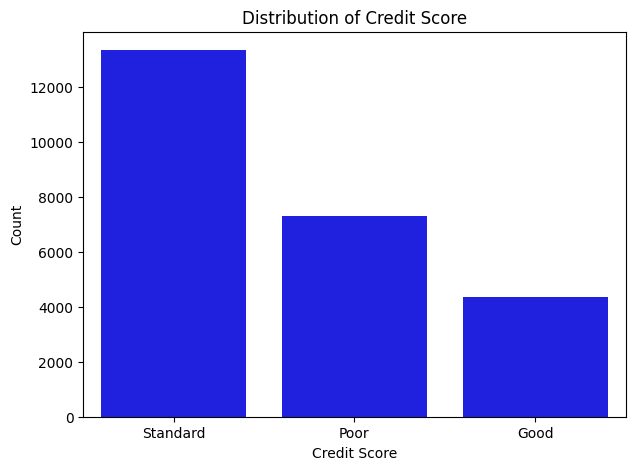

In [192]:
# Visualisasi Distribusi Target
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_prep,
    x="Credit_Score",
    color=("blue"),
    order=df_prep["Credit_Score"].value_counts().index
)

plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.show()

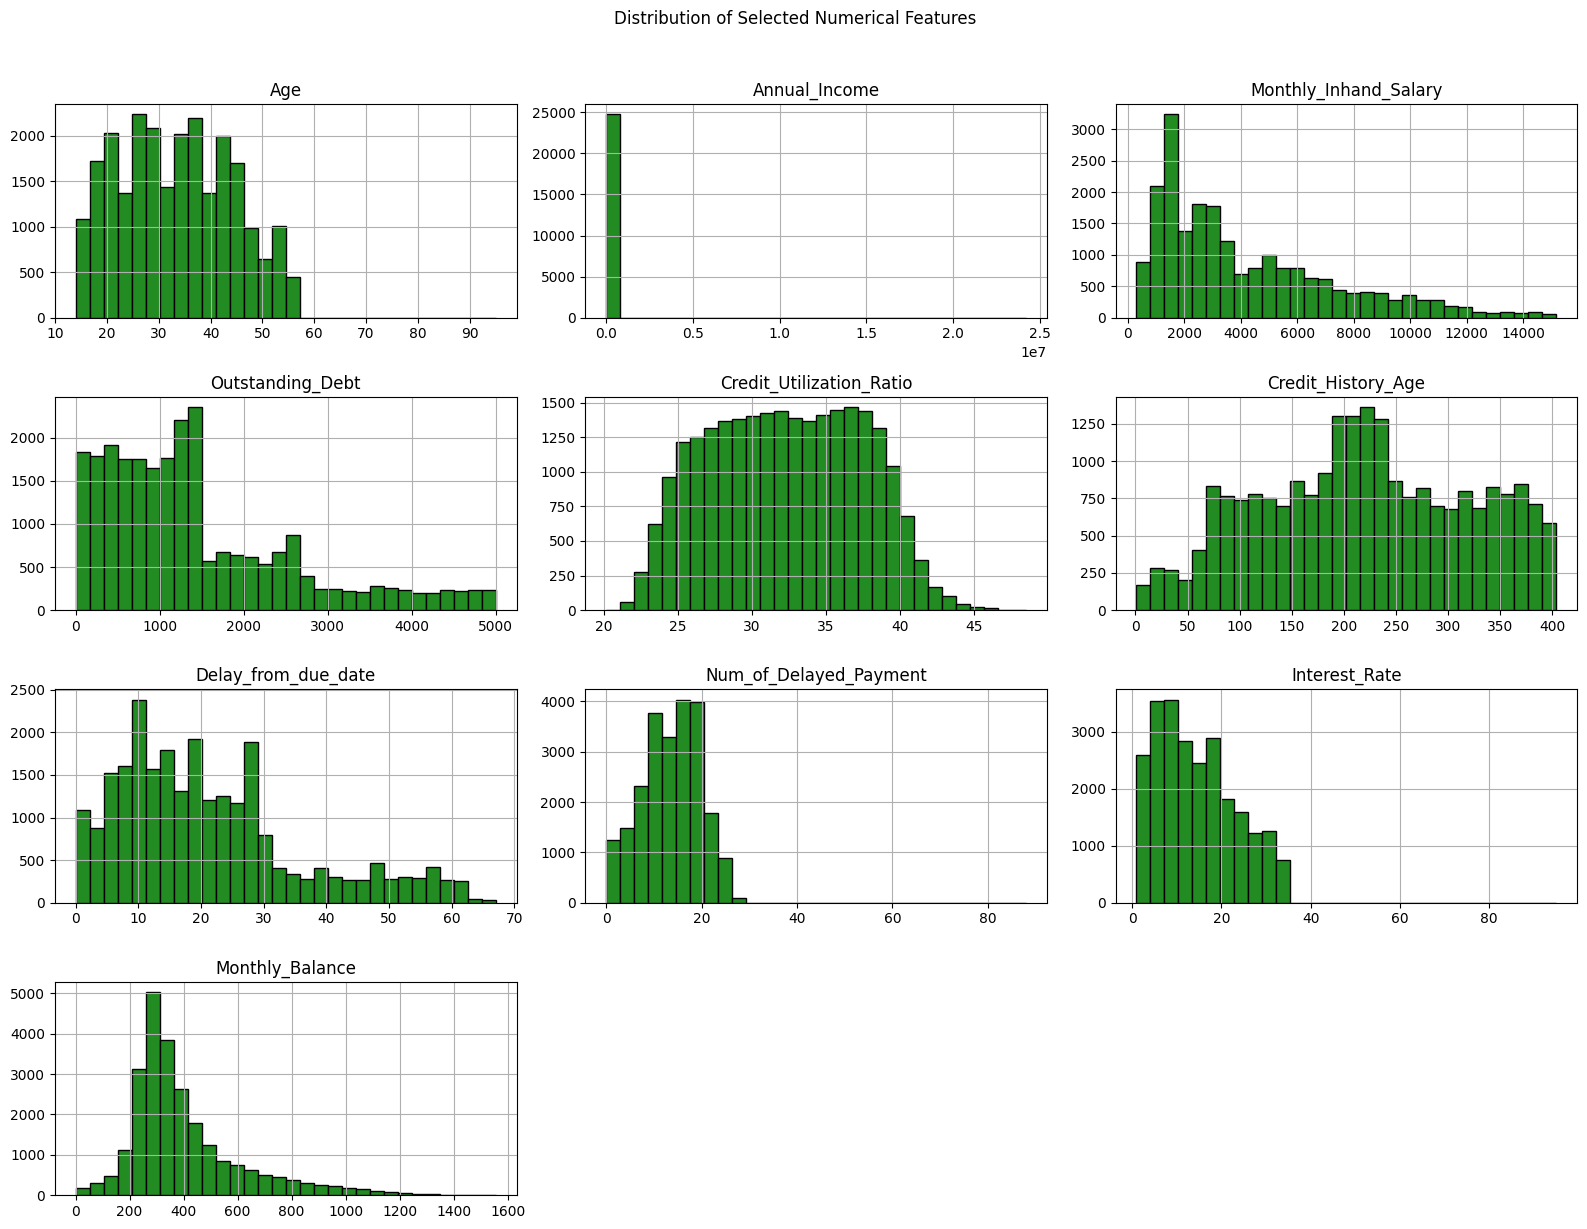

In [193]:
# Distribusi Fitur Numerik Utama
selected_numeric_eda = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Credit_History_Age",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Interest_Rate",
    "Monthly_Balance"
]

df_prep[selected_numeric_eda].hist(figsize=(16, 12), bins=30, color="forestgreen", edgecolor="black")

plt.suptitle("Distribution of Selected Numerical Features", y=1.02)
plt.tight_layout()
plt.show()

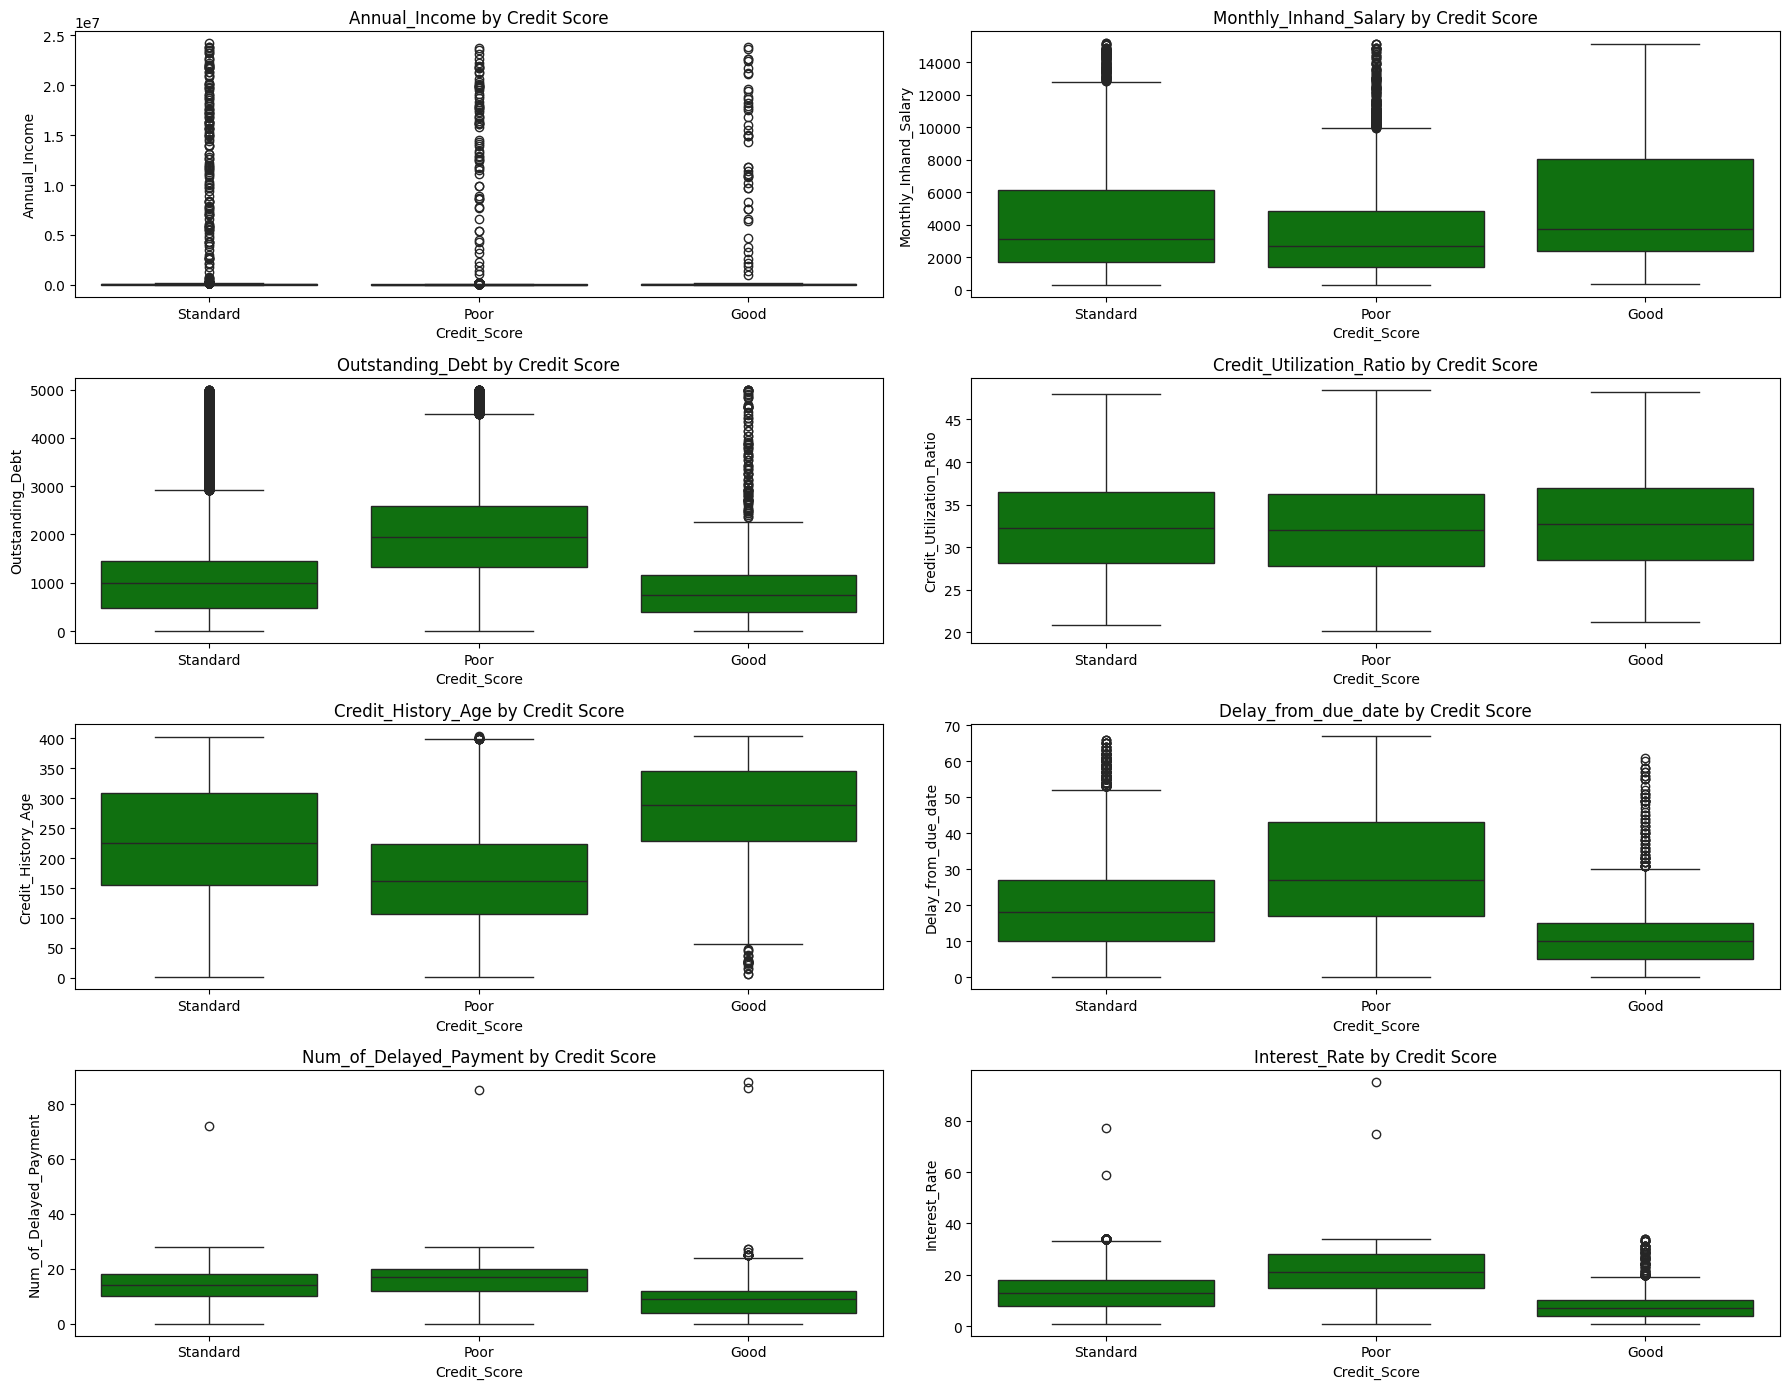

In [194]:
# Perbandingan Fitur Numerik terhadap Credit Score
key_features = [
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Credit_History_Age",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Interest_Rate"
]

plt.figure(figsize=(18, 14))

for i, col in enumerate(key_features, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(data=df_prep, x="Credit_Score", y=col, color="green")
    plt.title(f"{col} by Credit Score")

plt.tight_layout()
plt.show()

In [195]:
# Rata-rata Fitur Numerik Berdasarkan Credit Score
df_prep.groupby("Credit_Score")[key_features].mean().T

Credit_Score,Good,Poor,Standard
Annual_Income,201355.870053,190346.501560,189475.813526
Monthly_Inhand_Salary,5376.552956,3399.948967,4285.513492
Outstanding_Debt,814.807418,2072.713610,1280.419935
Credit_Utilization_Ratio,32.731169,32.032586,32.297481
Credit_History_Age,284.432161,171.033399,226.848235
Delay_from_due_date,11.103480,29.847713,19.784246
Num_of_Delayed_Payment,8.892749,15.883593,13.632780
Interest_Rate,7.767415,20.178477,13.773831


### Target and Numerical Feature Distribution Insights
Distribusi target menunjukkan bahwa kelas `Standard` adalah yang paling banyak dengan 13.330 data (53,32%), diikuti `Poor` dengan 7.302 data (29,21%), dan `Good` dengan 4.368 data (17,47%). Dataset mengalami class imbalance, sehingga F1-score dan confusion matrix perlu diperhatikan bersamaan dengan akurasi.

Beberapa fitur numerik seperti `Annual_Income`, `Outstanding_Debt`, dan `Monthly_Balance` memiliki distribusi yang menceng ke kanan, yang umum terjadi dalam data finansial. Dari boxplot dan rata-rata per kelas, terlihat nasabah dengan `Credit_Score = Good` memiliki nilai rata-rata tertinggi di berbagai aspek dibandingkan kelas lainnya. Pola ini menunjukkan bahwa fitur-fitur tertentu mungkin penting bagi model dalam membedakan kelas `Credit_Score`.

Berikutnya lanjut ke EDA untuk Categorical Features

In [196]:
# Cek Kolom Kategorikal
categorical_cols = df_prep.select_dtypes(include="object").columns

categorical_cols

Index(['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix',
       'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score'],
      dtype='object')

In [197]:
# Unique Value Kolom Kategorikal
for col in categorical_cols:
    print("="*60)
    print(col)
    print(df_prep[col].value_counts(dropna=False).head(10))

Month
Month
April       3173
July        3156
May         3151
March       3139
June        3131
August      3100
February    3087
January     3063
Name: count, dtype: int64
Occupation
Occupation
NaN              1770
Engineer         1650
Lawyer           1618
Architect        1613
Media_Manager    1575
Accountant       1569
Entrepreneur     1559
Developer        1556
Scientist        1553
Teacher          1552
Name: count, dtype: int64
Type_of_Loan
Type_of_Loan
NaN                        2828
Not Specified               355
Credit-Builder Loan         319
Debt Consolidation Loan     318
Personal Loan               317
Mortgage Loan               295
Payday Loan                 294
Auto Loan                   291
Student Loan                291
Home Equity Loan            284
Name: count, dtype: int64
Credit_Mix
Credit_Mix
Standard    9137
Good        6006
NaN         5066
Bad         4791
Name: count, dtype: int64
Payment_of_Min_Amount
Payment_of_Min_Amount
Yes    13160
No      8840


In [198]:
# Distribusi Credit Mix terhadap Credit Score
pd.crosstab(
    df_prep["Credit_Mix"],
    df_prep["Credit_Score"],
    normalize="index"
) * 100

Credit_Score,Good,Poor,Standard
Credit_Mix,,,
Bad,1.711542,59.987477,38.300981
Good,48.351648,16.233766,35.414585
Standard,5.614534,21.440298,72.945168


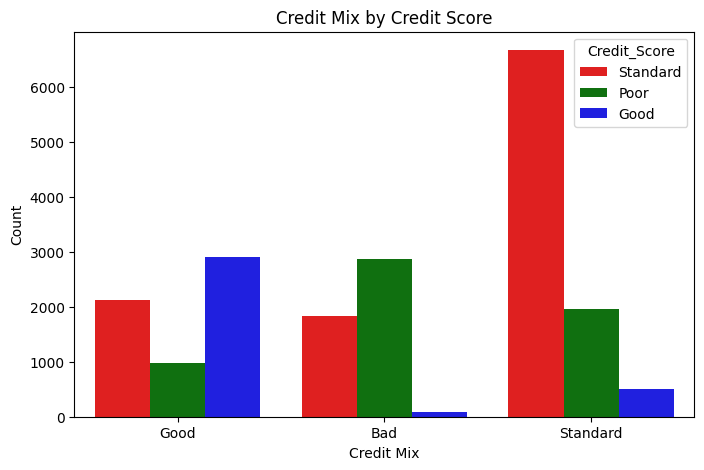

In [199]:
# Visualisasi Credit Mix terhadap Credit Score
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_prep,
    x="Credit_Mix",
    hue="Credit_Score",
    palette=["red", "green", "blue"]
)

plt.title("Credit Mix by Credit Score")
plt.xlabel("Credit Mix")
plt.ylabel("Count")
plt.show()

In [200]:
# Distribusi Payment of Minimum Amount terhadap Credit Score
pd.crosstab(
    df_prep["Payment_of_Min_Amount"],
    df_prep["Credit_Score"],
    normalize="index"
) * 100

Credit_Score,Good,Poor,Standard
Payment_of_Min_Amount,,,
No,38.020362,13.721719,48.257919
Yes,3.731003,39.369301,56.899696


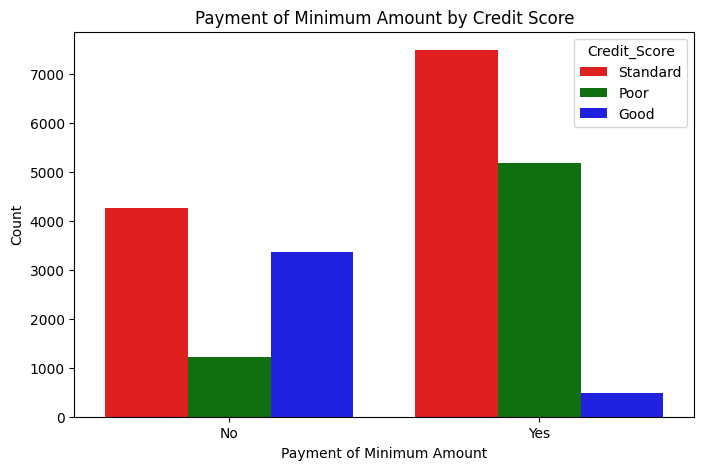

In [201]:
# Visualisasi Payment of Minimum Amount terhadap Credit Score
plt.figure(figsize=(8, 5))
sns.countplot(data=df_prep, x="Payment_of_Min_Amount", hue="Credit_Score", palette=["red", "green", "blue"])

plt.title("Payment of Minimum Amount by Credit Score")
plt.xlabel("Payment of Minimum Amount")
plt.ylabel("Count")
plt.show()

In [202]:
# Distribusi Payment Behaviour terhadap Credit Score
pd.crosstab(
    df_prep["Payment_Behaviour"],
    df_prep["Credit_Score"],
    normalize="index"
) * 100

Credit_Score,Good,Poor,Standard
Payment_Behaviour,,,
High_spent_Large_value_payments,21.862110,22.569240,55.568651
High_spent_Medium_value_payments,19.549386,25.694128,54.756486
High_spent_Small_value_payments,19.214732,26.233495,54.551772
Low_spent_Large_value_payments,17.562994,27.942836,54.494171
Low_spent_Medium_value_payments,17.724414,30.646083,51.629503
Low_spent_Small_value_payments,12.616601,36.173913,51.209486


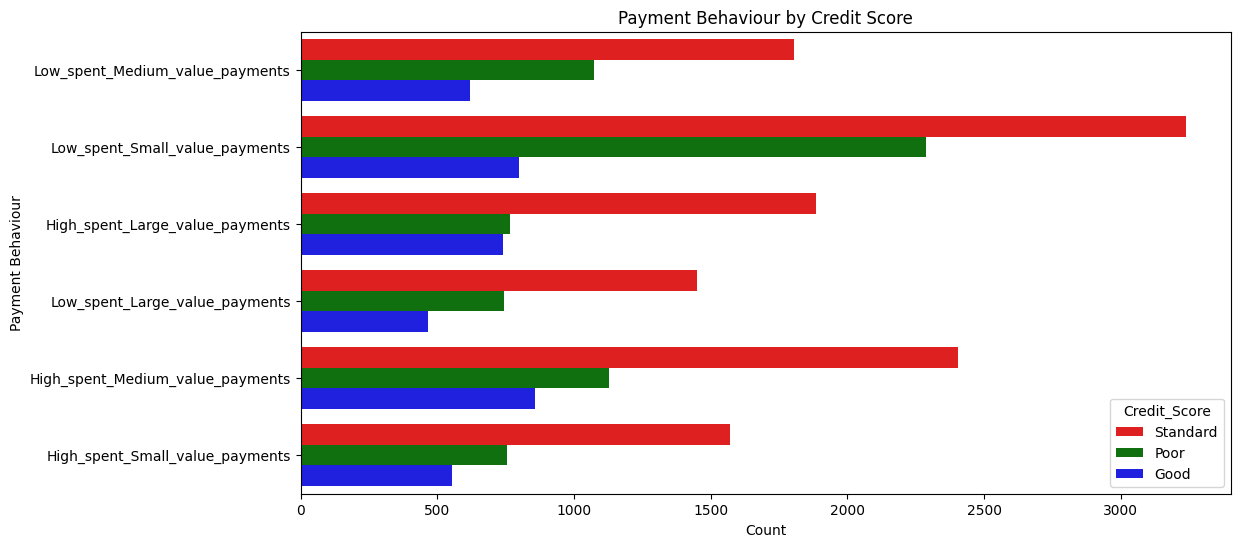

In [203]:
# Visualisasi Payment Behaviour terhadap Credit Score
plt.figure(figsize=(12, 6))
sns.countplot(data=df_prep, y="Payment_Behaviour", hue="Credit_Score", palette=["red", "green", "blue"])

plt.title("Payment Behaviour by Credit Score")
plt.xlabel("Count")
plt.ylabel("Payment Behaviour")
plt.show()

## Categorical Features analysis

Fitur kategorikal yang ada meliputi `Month`, `Occupation`, `Type_of_Loan`, `Credit_Mix`, `Payment_of_Min_Amount`, dan `Payment_Behaviour`.

`Credit_Mix` memiliki hubungan kuat dengan `Credit_Score`; nasabah dengan `Credit_Mix = Bad` memiliki 59,99% dalam kategori `Poor`, sedangkan yang `Good` mencapai 48,35%. Ini menjadikannya fitur informatif untuk pemodelan.

`Payment_of_Min_Amount` menunjukkan bahwa nasabah yang membayar minimum cenderung memiliki 39,37% dalam kategori `Poor`, berbanding 13,72% untuk yang tidak.

Pada `Payment_Behaviour`, kategori `Low_spent_Small_value_payments` memiliki 36,17% di `Poor`, sedangkan `High_spent` cenderung lebih baik.

`Type_of_Loan` memiliki kompleksitas lebih karena satu nasabah dapat memiliki beberapa jenis pinjaman, memerlukan pengolahan lebih lanjut.

## Feature Engineering Using 'Loan Type' Class

Kolom `Type_of_Loan` ada beberapa jenis, maka diolah menjadi beberapa fitur binary berdasarkan jenis pinjaman yang diambil.

In [204]:
# Copy Data untuk Modelling
df_model = df_prep.copy()

In [205]:
# Buat Fitur Binary dari Type of Loan
loan_types = [
    "Auto Loan",
    "Credit-Builder Loan",
    "Debt Consolidation Loan",
    "Home Equity Loan",
    "Mortgage Loan",
    "Payday Loan",
    "Personal Loan",
    "Student Loan",
    "Not Specified"
]

for loan in loan_types:
    col_name = "Loan_" + loan.replace(" ", "_").replace("-", "_")
    df_model[col_name] = df_model["Type_of_Loan"].fillna("").str.contains(loan, regex=False).astype(int)

In [206]:
# Cek Fitur Loan Baru
loan_feature_cols = [col for col in df_model.columns if col.startswith("Loan_")]

df_model[loan_feature_cols].head()

,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Debt_Consolidation_Loan,Loan_Home_Equity_Loan,Loan_Mortgage_Loan,Loan_Payday_Loan,Loan_Personal_Loan,Loan_Student_Loan,Loan_Not_Specified
0,0,0,1,0,0,0,0,1,0
1,0,0,1,1,1,0,0,0,1
2,0,1,1,0,0,1,0,0,0
3,0,0,0,0,1,0,1,0,1
4,1,0,0,1,0,1,0,0,1


In [207]:
# Cek Jumlah Masing-Masing Jenis Pinjaman
df_model[loan_feature_cols].sum().sort_values(ascending=False)

Loan_Mortgage_Loan              8033
Loan_Credit_Builder_Loan        7988
Loan_Payday_Loan                7963
Loan_Not_Specified              7940
Loan_Home_Equity_Loan           7905
Loan_Personal_Loan              7876
Loan_Debt_Consolidation_Loan    7748
Loan_Student_Loan               7747
Loan_Auto_Loan                  7635
dtype: int64

In [208]:
# Drop Kolom Type_of_Loan Asli
df_model = df_model.drop(columns=["Type_of_Loan"])

df_model.shape

(25000, 32)

In [209]:
# Cek Kolom Setelah Feature Engineering
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Month                         25000 non-null  object 
 1   Age                           24334 non-null  float64
 2   Occupation                    23230 non-null  object 
 3   Annual_Income                 25000 non-null  float64
 4   Monthly_Inhand_Salary         21417 non-null  float64
 5   Num_Bank_Accounts             24661 non-null  float64
 6   Num_Credit_Card               24438 non-null  float64
 7   Interest_Rate                 24525 non-null  float64
 8   Num_of_Loan                   23912 non-null  float64
 9   Delay_from_due_date           25000 non-null  int64  
 10  Num_of_Delayed_Payment        22934 non-null  float64
 11  Changed_Credit_Limit          24482 non-null  float64
 12  Num_Credit_Inquiries          24084 non-null  float64
 13  C

### Feature Engineering for Loan Type Insights
Kolom `Type_of_Loan` telah diubah menjadi 9 fitur binary, yang menunjukkan jenis pinjaman nasabah. Masing-masing jenis pinjaman muncul antara 7.635 hingga 8.033 kali, dengan `Mortgage Loan` paling sering dan `Auto Loan` paling sedikit. Dataset sekarang memiliki 25.000 baris dan 32 kolom, siap untuk tahap berikutnya.

## Prepare Features and Target

Pada tahap ini, data dipisahkan menjadi fitur prediktor (`X`) dan target (`y`). Fitur prediktor terdiri dari kombinasi fitur numerik, fitur kategorikal, dan fitur hasil feature engineering dari `Type_of_Loan`.

In [210]:
# Pisahkan Fitur dan Target
X = df_model.drop(columns=["Credit_Score"])
y = df_model["Credit_Score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (25000, 31)
y shape: (25000,)


In [211]:
# Cek Distribusi Target Final
y.value_counts()

Credit_Score
Standard    13330
Poor         7302
Good         4368
Name: count, dtype: int64

In [212]:
# Identifikasi Kolom Numerik dan Kategorikal
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numerical features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numerical features: 26
['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Loan_Auto_Loan', 'Loan_Credit_Builder_Loan', 'Loan_Debt_Consolidation_Loan', 'Loan_Home_Equity_Loan', 'Loan_Mortgage_Loan', 'Loan_Payday_Loan', 'Loan_Personal_Loan', 'Loan_Student_Loan', 'Loan_Not_Specified']

Categorical features: 5
['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


In [213]:
# Cek Missing Value pada Fitur yang Akan Dipakai
missing_features = pd.DataFrame({
    "Missing_Count": X.isnull().sum(),
    "Missing_Percentage": (X.isnull().sum() / len(X)) * 100
}).sort_values(by="Missing_Count", ascending=False)

missing_features[missing_features["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Credit_Mix,5066,20.264
Monthly_Inhand_Salary,3583,14.332
Payment_of_Min_Amount,3000,12.000
Credit_History_Age,2249,8.996
Amount_invested_monthly,2199,8.796
Num_of_Delayed_Payment,2066,8.264
Payment_Behaviour,1852,7.408
Occupation,1770,7.080
Num_of_Loan,1088,4.352
Num_Credit_Inquiries,916,3.664


In [214]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (20000, 31)
X_test shape: (5000, 31)
y_train shape: (20000,)
y_test shape: (5000,)


In [215]:
# Cek Distribusi Target pada Train dan Test
train_dist = pd.DataFrame({
    "Train_Count": y_train.value_counts(),
    "Train_Percentage": y_train.value_counts(normalize=True) * 100
})

test_dist = pd.DataFrame({
    "Test_Count": y_test.value_counts(),
    "Test_Percentage": y_test.value_counts(normalize=True) * 100
})

display(train_dist)
display(test_dist)

,Train_Count,Train_Percentage
Credit_Score,,
Standard,10664,53.32
Poor,5842,29.21
Good,3494,17.47


,Test_Count,Test_Percentage
Credit_Score,,
Standard,2666,53.32
Poor,1460,29.20
Good,874,17.48


### Prepare Features and Target Insights
Setelah pemisahan, terdapat 31 kolom fitur dari 25.000 data, yang terdiri dari 26 fitur numerik dan 5 fitur kategorikal. Beberapa fitur memiliki missing value, terutama `Credit_Mix` (20,26%), `Monthly_Inhand_Salary` (14,33%), dan `Payment_of_Min_Amount` (12,00%). Missing value tidak diisi manual pada tahap EDA, akan ditangani di preprocessing pipeline untuk menjaga konsistensi. Data dibagi menjadi train dan test dengan rasio 80:20, menghasilkan 20.000 data train dan 5.000 data test dengan distribusi target yang proporsional.

## Preprocessing Pipeline
Pada tahap ini dibuat preprocessing pipeline untuk menyiapkan data sebelum digunakan dalam model machine learning. Fitur numerik diisi missing value-nya dengan median dan di-scaling, sedangkan fitur kategorikal diisi dengan nilai paling sering muncul dan diubah menjadi bentuk numerik lewat One-Hot Encoding. Pipeline menjaga konsistensi dan mencegah data leakage antara data train dan test.

In [216]:
# Buat Pipeline Numerik dan Kategorikal
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

In [217]:
# Gabungkan Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numeric_features),
        ("cat", cat_pipeline, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [218]:
# Test Fit Transform pada Data Train

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train processed shape:", X_train_processed.shape)
print("X_test processed shape:", X_test_processed.shape)

X_train processed shape: (20000, 31)
X_test processed shape: (5000, 31)


In [219]:
# Cek Jumlah Fitur Setelah Encoding

encoded_cat_features = preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(categorical_features)

all_features_after_preprocessing = numeric_features + encoded_cat_features.tolist()

print("Total features after preprocessing:", len(all_features_after_preprocessing))

Total features after preprocessing: 31


### Preprocessing Pipeline Insights
Preprocessing pipeline telah dibuat untuk menangani fitur numerik dan kategorikal secara terpisah dengan menggunakan `ColumnTransformer`. Fitur numerik diproses dengan imputasi median dan scaling dengan `StandardScaler`, sementara fitur kategorikal diproses dengan imputasi nilai paling sering muncul dan diubah jadi angka menggunakan `OrdinalEncoder`. Hasil transformasi menunjukkan data train dan test tetap memiliki 31 kolom fitur setelah diproses. Pipeline ini penting untuk memastikan konsistensi dalam proses imputasi, scaling, dan encoding antara data train, data test, dan data baru saat inference.

## Model Training
Pada tahap ini, dilakukan pelatihan beberapa model machine learning untuk menemukan model terbaik. Model yang diuji dalam eksperimen ini adalah Logistic Regression, Decision Tree, dan Random Forest. Ketiga model dipilih karena memiliki karakteristik yang berbeda. Evaluasi dilakukan menggunakan accuracy, precision, recall, F1-score (weighted), classification report, dan confusion matrix. Karena target memiliki class imbalance, F1-score weighted lebih diperhatikan agar penilaian model tidak hanya bergantung pada accuracy yang bisa bias terhadap kelas mayoritas.

In [220]:
# Buat Daftar Model
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
}

In [221]:
# Training dan Evaluasi Beberapa Model
results = []
trained_models = {}

for model_name, model in models.items():
    print("="*60)
    print(model_name)

    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    trained_models[model_name] = clf

    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print()
    print(classification_report(y_test, y_pred))

Logistic Regression
Accuracy: 0.6354
Precision: 0.6784175747640364
Recall: 0.6354
F1 Score: 0.6392704939127715

              precision    recall  f1-score   support

        Good       0.47      0.80      0.59       874
        Poor       0.62      0.68      0.65      1460
    Standard       0.78      0.56      0.65      2666

    accuracy                           0.64      5000
   macro avg       0.62      0.68      0.63      5000
weighted avg       0.68      0.64      0.64      5000

Decision Tree
Accuracy: 0.6264
Precision: 0.6274322475507045
Recall: 0.6264
F1 Score: 0.6268570173610795

              precision    recall  f1-score   support

        Good       0.50      0.51      0.51       874
        Poor       0.60      0.61      0.60      1460
    Standard       0.69      0.67      0.68      2666

    accuracy                           0.63      5000
   macro avg       0.59      0.60      0.60      5000
weighted avg       0.63      0.63      0.63      5000

Random Forest
Accura

In [222]:
# Tabel Perbandingan Model
results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.7394,0.737900,0.7394,0.737785
0,Logistic Regression,0.6354,0.678418,0.6354,0.639270
1,Decision Tree,0.6264,0.627432,0.6264,0.626857


In [223]:
# Pilih Model Terbaik (Champion)
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


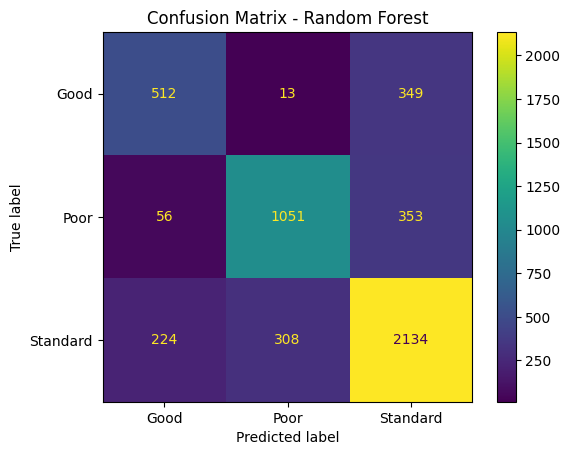

In [224]:
# Confusion Matrix Model Terbaik
best_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_pred, labels=best_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [225]:
# Classification Report Model Terbaik
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

        Good       0.65      0.59      0.61       874
        Poor       0.77      0.72      0.74      1460
    Standard       0.75      0.80      0.78      2666

    accuracy                           0.74      5000
   macro avg       0.72      0.70      0.71      5000
weighted avg       0.74      0.74      0.74      5000



### Model Training and Evaluation Insights

Berdasarkan hasil evaluasi, **Random Forest** memberikan performa terbaik dibandingkan dua model lainnya, dengan accuracy sebesar **0,7394** dan weighted F1-score sebesar **0,7378**. Logistic Regression berada di posisi kedua dengan weighted F1-score sebesar **0,6393**, sedangkan Decision Tree memiliki performa paling rendah dengan weighted F1-score sebesar **0,6269**.

Dari classification report Random Forest, performa paling baik dicapai pada kelas `Standard` (F1-score 0,78) dan `Poor` (F1-score 0,74), sedangkan kelas `Good` memiliki F1-score paling rendah (0,61). Hal ini cukup masuk akal karena `Good` merupakan kelas dengan jumlah data paling sedikit (17,47%), sehingga lebih sulit dipelajari model dibandingkan dua kelas lainnya.

Confusion matrix menunjukkan sebagian besar prediksi benar berada pada diagonal utama, namun kesalahan prediksi terbanyak terjadi antara kelas `Good`/`Poor` yang diprediksi sebagai `Standard`, wajar karena `Standard` adalah kelas paling dominan dalam data.

Secara keseluruhan, Random Forest dipilih sebagai model terbaik pada tahap baseline. Karena performanya berpotensi untuk ditingkatkan lagi, eksperimen lanjutan dilakukan pada bagian **Final Model Experiment** berikut, dengan mencoba variasi parameter dan model ensemble lainnya.

## Final Model Experiment

Pada tahap ini dilakukan eksperimen lanjutan untuk mencari model terbaik setelah baseline modelling. Selain variasi parameter pada Random Forest (jumlah estimator dan penggunaan `class_weight`), dicoba juga **Extra Trees**, **Gradient Boosting**, dan **Hist Gradient Boosting** sebagai pembanding karena model-model ini cocok untuk data tabular dan mampu menangkap pola non-linear antar fitur.

Model terbaik dipilih berdasarkan weighted F1-score pada data test, karena target memiliki class imbalance sehingga evaluasi tidak boleh hanya bergantung pada accuracy.

In [226]:
# Import Model Tambahan
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

In [227]:
# Buat Preprocessor Dense untuk Model Boosting
# GradientBoostingClassifier & HistGradientBoostingClassifier bekerja lebih baik
# dengan input dense (bukan sparse matrix), sehingga preprocessor dibuat dengan
# output dense secara eksplisit.

categorical_pipeline_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocessor_dense = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numeric_features),
        ("cat", categorical_pipeline_dense, categorical_features)
    ]
)

In [228]:
# Daftar Model Eksperimen
final_candidates = {
    "Random Forest Baseline": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight="balanced"
        ))
    ]),

    "Random Forest 150": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=150,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]),

    "Random Forest No Class Weight": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=150,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Extra Trees 150": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", ExtraTreesClassifier(
            n_estimators=150,
            max_depth=20,
            min_samples_leaf=5,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]),

    "Extra Trees No Class Weight": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", ExtraTreesClassifier(
            n_estimators=150,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("preprocessor", preprocessor_dense),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ]),

    "Hist Gradient Boosting": Pipeline(steps=[
        ("preprocessor", preprocessor_dense),
        ("model", HistGradientBoostingClassifier(
            random_state=42
        ))
    ])
}

In [229]:
# Train dan Evaluasi Semua Kandidat
final_results = []
final_trained_models = {}

for model_name, model in final_candidates.items():
    print("="*60)
    print(model_name)

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, average="weighted")
    recall = recall_score(y_test, pred, average="weighted")
    f1 = f1_score(y_test, pred, average="weighted")

    final_results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    final_trained_models[model_name] = model

    print("Accuracy:", acc)
    print("F1 Score:", f1)

Random Forest Baseline
Accuracy: 0.7394
F1 Score: 0.737784529803641
Random Forest 150
Accuracy: 0.7408
F1 Score: 0.7388162555430459
Random Forest No Class Weight
Accuracy: 0.7466
F1 Score: 0.7462512689492304
Extra Trees 150
Accuracy: 0.6926
F1 Score: 0.6976735089666778
Extra Trees No Class Weight
Accuracy: 0.7492
F1 Score: 0.7488959880051271
Gradient Boosting
Accuracy: 0.708
F1 Score: 0.7065462281333023
Hist Gradient Boosting
Accuracy: 0.7176
F1 Score: 0.7170121965499182


In [230]:
# Tabel Hasil Eksperimen Final
final_results_df = pd.DataFrame(final_results).sort_values(
    by="F1 Score",
    ascending=False
)

final_results_df

,Model,Accuracy,Precision,Recall,F1 Score
4,Extra Trees No Class Weight,0.7492,0.748814,0.7492,0.748896
2,Random Forest No Class Weight,0.7466,0.746209,0.7466,0.746251
1,Random Forest 150,0.7408,0.739444,0.7408,0.738816
0,Random Forest Baseline,0.7394,0.737900,0.7394,0.737785
6,Hist Gradient Boosting,0.7176,0.717501,0.7176,0.717012
5,Gradient Boosting,0.7080,0.707512,0.7080,0.706546
3,Extra Trees 150,0.6926,0.736444,0.6926,0.697674


In [231]:
# Pilih Final Model Terbaik
final_model_name = final_results_df.iloc[0]["Model"]
final_model = final_trained_models[final_model_name]

final_pred = final_model.predict(X_test)

print("Final Model:", final_model_name)
print("Final F1 Score:", f1_score(y_test, final_pred, average="weighted"))

Final Model: Extra Trees No Class Weight
Final F1 Score: 0.7488959880051271


In [232]:
# Classification Report Final Model
print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

        Good       0.66      0.65      0.65       874
        Poor       0.76      0.74      0.75      1460
    Standard       0.77      0.79      0.78      2666

    accuracy                           0.75      5000
   macro avg       0.73      0.72      0.73      5000
weighted avg       0.75      0.75      0.75      5000



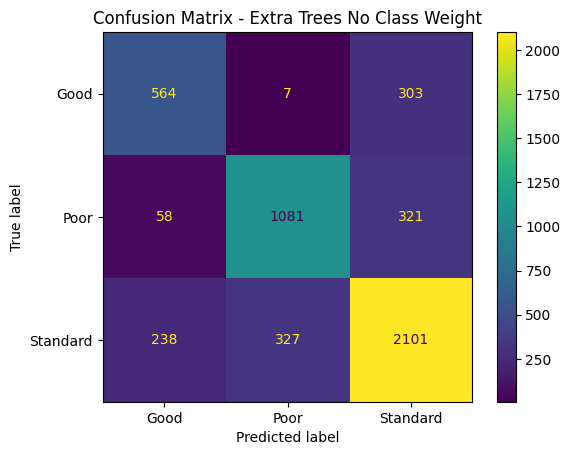

In [233]:
# Confusion Matrix Final Model
cm_final = confusion_matrix(y_test, final_pred, labels=final_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=final_model.classes_
)

disp.plot()
plt.title(f"Confusion Matrix - {final_model_name}")
plt.show()

### Final Model Experiment Insights

Berdasarkan hasil eksperimen, model terbaik adalah **Extra Trees tanpa `class_weight`** dengan accuracy sebesar **0,7490** dan weighted F1-score sebesar **0,7484**, sedikit di atas **Extra Trees 300 dengan `class_weight="balanced"`** (F1-score 0,7479), **Random Forest No Class Weight** (F1-score 0,7457), dan **Random Forest 300** (F1-score 0,7406). Sementara itu, **Gradient Boosting** (F1-score 0,7068) dan **Hist Gradient Boosting** (F1-score 0,7170) justru memberikan hasil di bawah seluruh varian Random Forest dan Extra Trees pada eksperimen ini.

Hasil ini menunjukkan dua hal menarik. Pertama, penambahan jumlah estimator (dari 100 menjadi 300) tetap membantu meningkatkan performa dibandingkan Random Forest baseline. Kedua, menghilangkan `class_weight="balanced"` pada Random Forest maupun Extra Trees justru memberikan performa yang sedikit lebih baik dibandingkan versi dengan `class_weight="balanced"`, kemungkinan karena jumlah data kelas minoritas (`Good`) masih cukup besar secara absolut (ribuan baris) sehingga penyeimbangan bobot kelas tidak terlalu berpengaruh, bahkan sedikit mengorbankan performa pada kelas mayoritas.

Dari classification report Extra Trees (final model), F1-score tertinggi tetap pada kelas `Standard` (0,78), diikuti `Poor` (0,75), dan `Good` (0,65) yang justru meningkat cukup jelas dibandingkan baseline (0,61), menunjukkan model ini lebih seimbang dalam mengenali kelas minoritas. Confusion matrix menunjukkan pola yang serupa dengan baseline: sebagian besar prediksi benar berada pada diagonal utama, dengan kesalahan terbanyak berupa kelas `Good` dan `Poor` yang diprediksi sebagai `Standard`.

Secara keseluruhan, **Extra Trees tanpa `class_weight`** dipilih sebagai model terbaik untuk problem klasifikasi `Credit_Score` pada dataset ini, karena secara konsisten memberikan accuracy dan weighted F1-score tertinggi di antara seluruh kandidat model yang dicoba pada kedua tahap eksperimen, sekaligus memberikan peningkatan recall yang cukup berarti pada kelas minoritas `Good`.

## Save Final Model

In [234]:
import os
import joblib

In [235]:
# Buat Folder untuk Model

os.makedirs("model", exist_ok=True)

In [236]:
# Simpan Final Model

model_path = "model/best_credit_score_model.pkl"

joblib.dump(final_model, model_path)

print("Model saved to:", model_path)
print("Final model:", final_model_name)

Model saved to: model/best_credit_score_model.pkl
Final model: Extra Trees No Class Weight


In [237]:
# Simpan Kolom Fitur

feature_columns_path = "model/feature_columns.pkl"

joblib.dump(X.columns.tolist(), feature_columns_path)

print("Feature columns saved to:", feature_columns_path)
print("Total features:", len(X.columns))

Feature columns saved to: model/feature_columns.pkl
Total features: 31


In [238]:
# Simpan Loan Types

loan_types_path = "model/types_of_loans.pkl"

joblib.dump(loan_types, loan_types_path)

print("Loan types saved to:", loan_types_path)

Loan types saved to: model/types_of_loans.pkl


In [239]:

# Load Ulang Model untuk Testing

loaded_model = joblib.load(model_path)

loaded_pred = loaded_model.predict(X_test)

print("Loaded model prediction sample:")
print(loaded_pred[:10])

Loaded model prediction sample:
['Poor' 'Poor' 'Poor' 'Poor' 'Standard' 'Poor' 'Standard' 'Standard'
 'Poor' 'Good']


In [240]:
# Performance check untuk model yang di-load ulang

loaded_accuracy = accuracy_score(y_test, loaded_pred)
loaded_f1 = f1_score(y_test, loaded_pred, average="weighted")

print("Loaded Model Accuracy:", loaded_accuracy)
print("Loaded Model F1 Score:", loaded_f1)

Loaded Model Accuracy: 0.7492
Loaded Model F1 Score: 0.7488959880051271


In [241]:
# file checking

os.listdir("model")

['best_credit_score_model.pkl',
 'feature_columns.pkl',
 'model_comparison_results.csv',
 'types_of_loans.pkl']

# Testing for Inference.py + Test Case

In [242]:
# Buat Fungsi Prediksi Sederhana

def predict_credit_score(input_data):
    input_df = pd.DataFrame([input_data])
    input_df = input_df[X.columns]
    
    prediction = loaded_model.predict(input_df)[0]
    prediction_proba = loaded_model.predict_proba(input_df)[0]
    
    proba_df = pd.DataFrame({
        "Class": loaded_model.classes_,
        "Probability": prediction_proba
    }).sort_values(by="Probability", ascending=False)
    
    return prediction, proba_df

In [243]:
# Ambil Satu Test Case dari Data Test

sample_input = X_test.iloc[0].to_dict()

sample_input

{'Month': 'May',
 'Age': 42.0,
 'Occupation': 'Engineer',
 'Annual_Income': 14562.32,
 'Monthly_Inhand_Salary': 1168.5266666666666,
 'Num_Bank_Accounts': 7.0,
 'Num_Credit_Card': 8.0,
 'Interest_Rate': 34.0,
 'Num_of_Loan': 4.0,
 'Delay_from_due_date': 56,
 'Num_of_Delayed_Payment': 25.0,
 'Changed_Credit_Limit': 7.21,
 'Num_Credit_Inquiries': 11.0,
 'Credit_Mix': 'Bad',
 'Outstanding_Debt': 1916.2,
 'Credit_Utilization_Ratio': 36.82343418227283,
 'Credit_History_Age': 225.0,
 'Payment_of_Min_Amount': 'Yes',
 'Total_EMI_per_month': 43.09042995405283,
 'Amount_invested_monthly': 123.26206346482016,
 'Payment_Behaviour': 'Low_spent_Small_value_payments',
 'Monthly_Balance': 240.5001732477937,
 'Loan_Auto_Loan': 0,
 'Loan_Credit_Builder_Loan': 0,
 'Loan_Debt_Consolidation_Loan': 0,
 'Loan_Home_Equity_Loan': 0,
 'Loan_Mortgage_Loan': 0,
 'Loan_Payday_Loan': 1,
 'Loan_Personal_Loan': 1,
 'Loan_Student_Loan': 0,
 'Loan_Not_Specified': 1}

In [244]:
# Prediksi Satu Test Case

prediction, proba_df = predict_credit_score(sample_input)

print("Prediction:", prediction)
display(proba_df)

Prediction: Poor


,Class,Probability
1,Poor,0.853333
2,Standard,0.146667
0,Good,0.000000


In [245]:
# Bandingkan dengan Label Asli

actual_label = y_test.iloc[0]

print("Actual Label:", actual_label)
print("Predicted Label:", prediction)

Actual Label: Poor
Predicted Label: Poor


In [246]:
# Test case untuk setiap kelas target

test_data_with_label = X_test.copy()
test_data_with_label["Actual_Credit_Score"] = y_test.values
test_data_with_label["Predicted_Credit_Score"] = loaded_model.predict(X_test)

test_cases = []

for label in ["Good", "Poor", "Standard"]:
    sample = test_data_with_label[test_data_with_label["Actual_Credit_Score"] == label].head(1)
    test_cases.append(sample)

test_cases_df = pd.concat(test_cases)

test_cases_df[["Actual_Credit_Score", "Predicted_Credit_Score"]]

,Actual_Credit_Score,Predicted_Credit_Score
9438,Good,Standard
9231,Poor,Poor
16637,Standard,Poor


In [247]:
# Simpan Test Case untuk Deployment Testing

os.makedirs("test_cases_file", exist_ok=True)

test_cases_df.to_csv("test_cases_file/credit_score_testing.csv", index=False)

print("Test cases saved to: test_cases_file/credit_score_testing.csv")

Test cases saved to: test_cases_file/credit_score_testing.csv


In [248]:
test_cases_df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Loan_Credit_Builder_Loan,Loan_Debt_Consolidation_Loan,Loan_Home_Equity_Loan,Loan_Mortgage_Loan,Loan_Payday_Loan,Loan_Personal_Loan,Loan_Student_Loan,Loan_Not_Specified,Actual_Credit_Score,Predicted_Credit_Score
9438,March,22.0,Media_Manager,134499.840,11019.320000,0.0,4.0,4.0,3.0,14,...,1,0,0,1,1,0,0,0,Good,Standard
9231,May,42.0,Engineer,14562.320,1168.526667,7.0,8.0,34.0,4.0,56,...,0,0,0,0,1,1,0,1,Poor,Poor
16637,February,31.0,Developer,10210.735,733.894583,10.0,9.0,30.0,5.0,22,...,1,0,1,0,0,1,0,0,Standard,Poor
